# Step 1 — Load your cleaned dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

df = pd.read_csv("/content/cleaned_fake_job_postings.csv")

# Remove the one record with missing target
df = df.dropna(subset=["fraudulent"])

print("Shape:", df.shape)

Shape: (6840, 19)


# Step 2 — Create readable labels

In [ ]:
df["Fraud Status"] = df["fraudulent"].map({
    0: "Genuine",
    1: "Fraudulent"
})

df["Company Logo"] = df["has_company_logo"].map({
    0: "No Logo",
    1: "Logo"
})

# Step 3 — Create the contingency table

In [ ]:
contingency_table = pd.crosstab(
    df["Company Logo"],
    df["Fraud Status"]
)

print(contingency_table)

Fraud Status  Fraudulent  Genuine
Company Logo                     
Logo                 126     5159
No Logo              189     1366


# Step 4 — Visualize the relationship

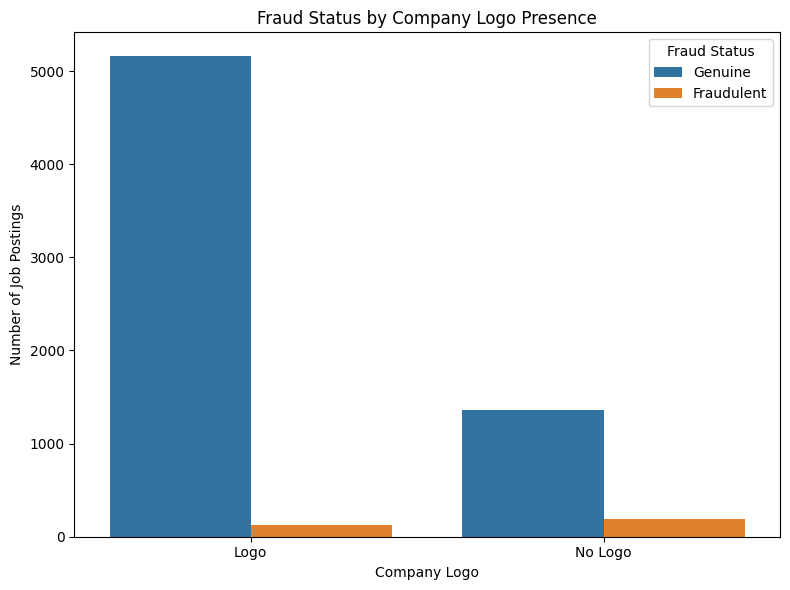

In [ ]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x="Company Logo",
    hue="Fraud Status"
)

plt.title("Fraud Status by Company Logo Presence")
plt.xlabel("Company Logo")
plt.ylabel("Number of Job Postings")

plt.tight_layout()
plt.savefig("logo_vs_fraud.png", dpi=300)
plt.show()

# Step 5 — Calculate fraud rates

In [ ]:
fraud_rate = (
    df.groupby("Company Logo")["fraudulent"]
    .mean() * 100
)

print(fraud_rate)

Company Logo
Logo        2.384106
No Logo    12.154341
Name: fraudulent, dtype: float64


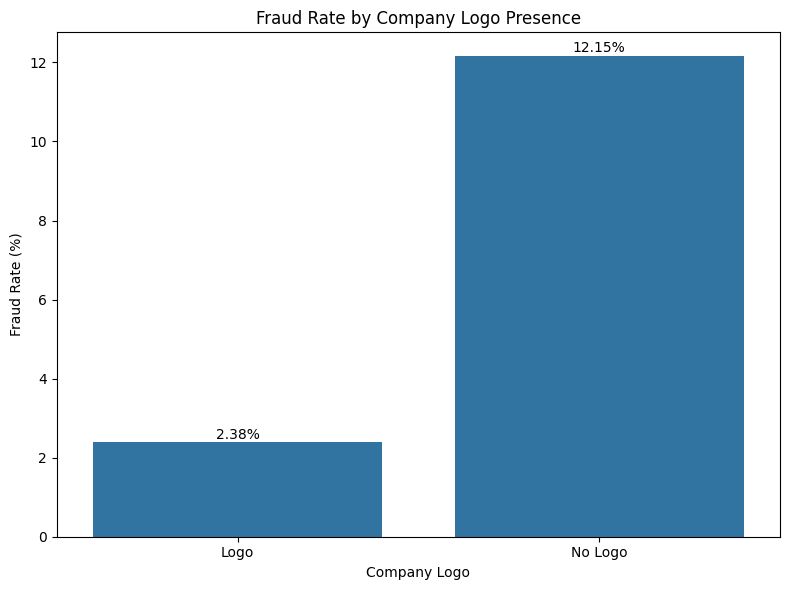

In [ ]:
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x=fraud_rate.index,
    y=fraud_rate.values
)

plt.title("Fraud Rate by Company Logo Presence")
plt.xlabel("Company Logo")
plt.ylabel("Fraud Rate (%)")

for i, value in enumerate(fraud_rate.values):
    ax.text(
        i,
        value + 0.1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.savefig("fraud_rate_by_logo.png", dpi=300)
plt.show()

# Step 6 — Perform the Chi-Square test

In [ ]:
chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", degrees_of_freedom)

Chi-Square Statistic: 258.8468469536185
P-value: 3.061103938367776e-58
Degrees of Freedom: 1


In [ ]:
expected_table = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print("\nExpected Frequencies:")
print(expected_table)


Expected Frequencies:
Fraud Status  Fraudulent      Genuine
Company Logo                         
Logo          243.388158  5041.611842
No Logo        71.611842  1483.388158


# Step 7 — Automatically generate the conclusion

In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant association between company logo presence and fraud status.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence to conclude a statistically significant association.")

Reject the null hypothesis.
There is a statistically significant association between company logo presence and fraud status.


# Step 8 — Add another statistical test

For a stronger Week 3 submission, I recommend adding a second hypothesis.

Hypothesis 2

Is there a statistically significant association between having screening questions and fraud status?

H₀: has_questions and fraudulent are independent.

H₁: has_questions and fraudulent are associated.

In [ ]:
questions_table = pd.crosstab(
    df["has_questions"],
    df["fraudulent"]
)

print(questions_table)

chi2_q, p_q, dof_q, expected_q = chi2_contingency(
    questions_table
)

print("Chi-Square Statistic:", chi2_q)
print("P-value:", p_q)
print("Degrees of Freedom:", dof_q)

fraudulent      0.0  1.0
has_questions           
0              2933  210
1              3592  105
Chi-Square Statistic: 56.18898642812057
P-value: 6.582925302124579e-14
Degrees of Freedom: 1


In [ ]:
if p_q < 0.05:
    print("Reject H0: There is a significant association.")
else:
    print("Fail to reject H0: There is not enough evidence of an association.")

Reject H0: There is a significant association.


# Step 9 — Third analysis: telecommuting

In [ ]:
telecommuting_table = pd.crosstab(
    df["telecommuting"],
    df["fraudulent"]
)

chi2_t, p_t, dof_t, expected_t = chi2_contingency(
    telecommuting_table
)

print("Chi-Square Statistic:", chi2_t)
print("P-value:", p_t)
print("Degrees of Freedom:", dof_t)

Chi-Square Statistic: 5.5049225161709
P-value: 0.01896302036266788
Degrees of Freedom: 1


In [ ]:
results = pd.DataFrame({
    "Test": [
        "Company Logo vs Fraud",
        "Questions vs Fraud",
        "Telecommuting vs Fraud"
    ],
    "Chi-Square": [
        chi2,
        chi2_q,
        chi2_t
    ],
    "P-Value": [
        p_value,
        p_q,
        p_t
    ]
})

results["Significant (α=0.05)"] = results["P-Value"] < 0.05

results

,Test,Chi-Square,P-Value,Significant (α=0.05)
0,Company Logo vs Fraud,258.846847,3.061104e-58,True
1,Questions vs Fraud,56.188986,6.582925e-14,True
2,Telecommuting vs Fraud,5.504923,1.896302e-02,True


# Step 10 — Visualizations for Week 3

Visualization 3

Screening Questions vs Fraud Status

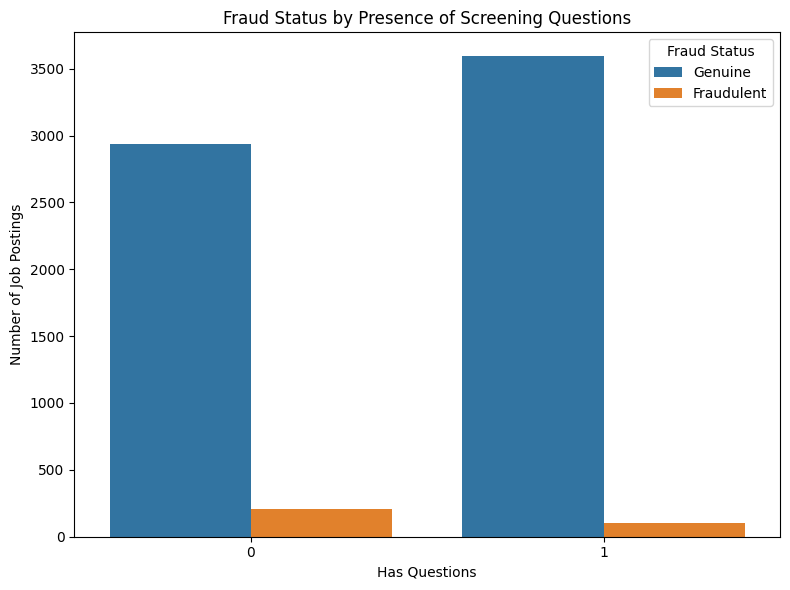

In [ ]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x="has_questions",
    hue="Fraud Status"
)

plt.title("Fraud Status by Presence of Screening Questions")
plt.xlabel("Has Questions")
plt.ylabel("Number of Job Postings")

plt.tight_layout()
plt.savefig("questions_vs_fraud.png", dpi=300)
plt.show()

Visualization 4

Telecommuting vs Fraud Status

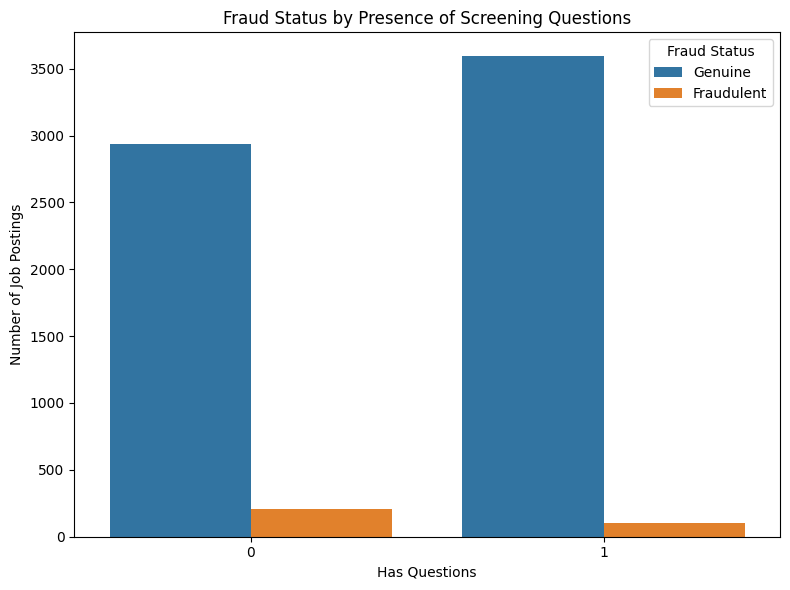

In [ ]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x="has_questions",
    hue="Fraud Status"
)

plt.title("Fraud Status by Presence of Screening Questions")
plt.xlabel("Has Questions")
plt.ylabel("Number of Job Postings")

plt.tight_layout()
plt.savefig("questions_vs_fraud.png", dpi=300)
plt.show()

Visualization 4

Telecommuting vs Fraud Status

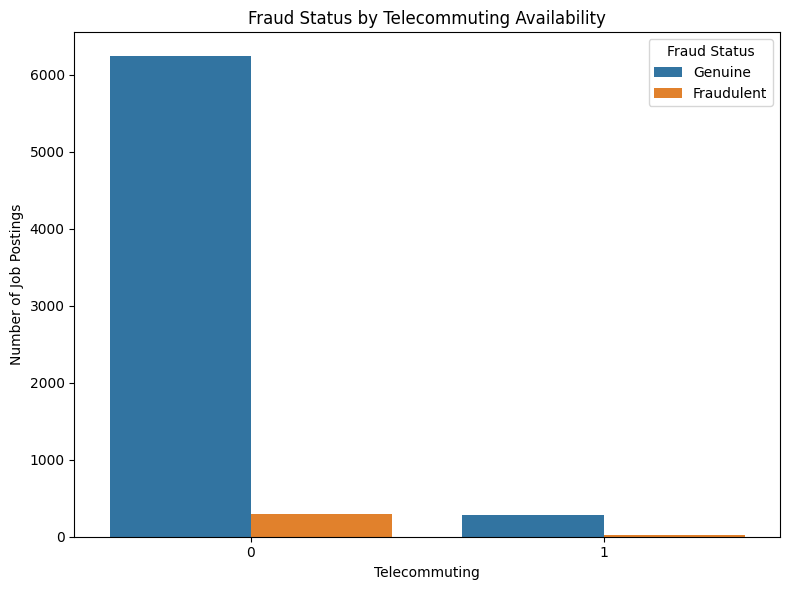

In [ ]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x="telecommuting",
    hue="Fraud Status"
)

plt.title("Fraud Status by Telecommuting Availability")
plt.xlabel("Telecommuting")
plt.ylabel("Number of Job Postings")

plt.tight_layout()
plt.savefig("telecommuting_vs_fraud.png", dpi=300)
plt.show()